<a href="https://colab.research.google.com/github/HFAJIR/GenAI_ML_Bootcamp/blob/main/Week4/Day_2/daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files


In [ ]:
uploaded = files.upload()


Saving imdb_top_1000.csv to imdb_top_1000 (5).csv


In [ ]:
# Charger le dataset
df = pd.read_csv('imdb_top_1000.csv')  # ou remplacer par le chemin correct

# Inspecter les premières lignes
print(df.head())

# Informations générales
print(df.info())

# Statistiques descriptives
print(df.describe())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [ ]:
df[df['Gross'].apply(lambda x: pd.to_numeric(x, errors='coerce')).isna()]['Gross'].unique()


array([nan])

In [ ]:
df['Gross'] = df['Gross'].str.replace(',', '', regex=True).astype(float)


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(3), int64(1), object(12)
memory usage: 125.1+ KB
None


In [ ]:
non_numeric_years = df[df['Released_Year'].apply(lambda x: pd.to_numeric(x, errors='coerce')).isna()]['Released_Year']  # verifier in colums Released_Year where is objet rows

print(non_numeric_years)

966    PG
Name: Released_Year, dtype: object


In [ ]:
df = df[pd.to_numeric(df['Released_Year'], errors='coerce').notna()]


In [ ]:
df['Released_Year'] = df['Released_Year'].astype(int)


In [ ]:
print(df['Released_Year'].dtype)


int64


In [ ]:
# Supprimer " min" et convertir en entier
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)

# Vérifier
print(df['Runtime'].dtype)
print(df['Runtime'].head())


int64
0    142
1    175
2    152
3    202
4     96
Name: Runtime, dtype: int64


In [ ]:
print(df.isnull().sum())


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate        0
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score         0
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [ ]:
mean_gross = df['Gross'].mean()
std_gross = df['Gross'].std()

cv_gross = (std_gross / mean_gross) * 100
print("Coefficient de variation de Gross (%) :", cv_gross)

Coefficient de variation de Gross (%) : 161.6242749654883


In [ ]:
median_gross = df['Gross'].median()
df['Gross'].fillna(median_gross, inplace=True)


/tmp/ipython-input-545456805.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gross'].fillna(median_gross, inplace=True)


In [ ]:
print(df.isnull().sum())


Poster_Link      0
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64


**2️ Rating Trends Over Years (ligne du temps des notes IMDB)**

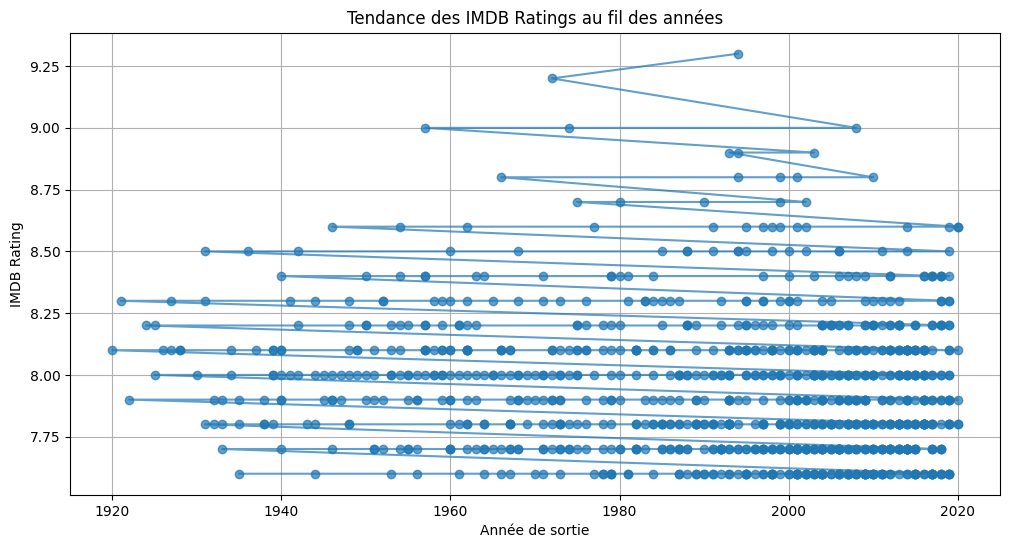

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['Released_Year'], df['IMDB_Rating'], marker='o', linestyle='-', alpha=0.7)
plt.title("Tendance des IMDB Ratings au fil des années")
plt.xlabel("Année de sortie")
plt.ylabel("IMDB Rating")
plt.grid(True)
plt.show()


**3️ Genre Popularity Analysis (popularité des genres)**

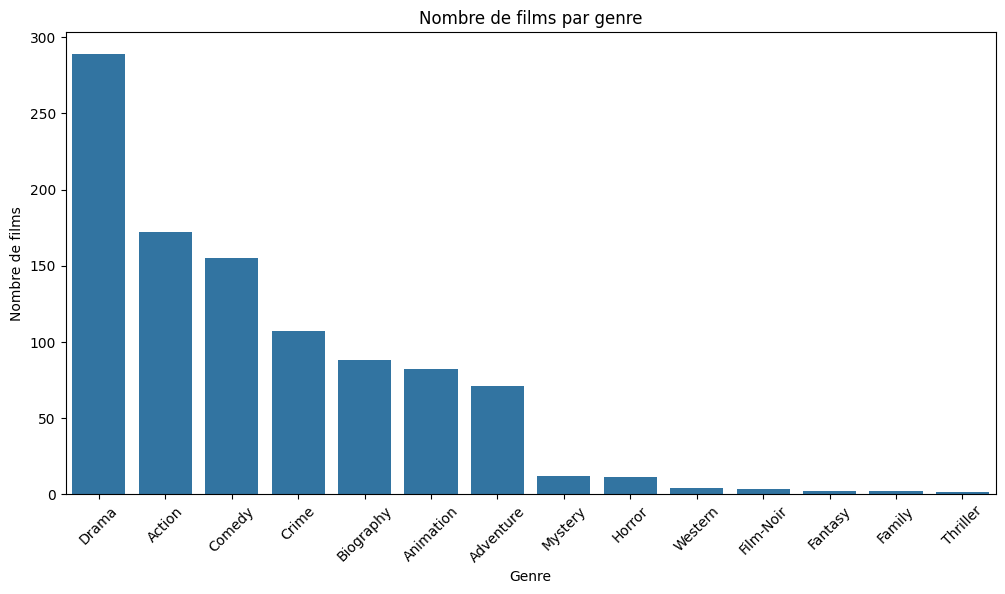

In [ ]:
# Si plusieurs genres par film, prendre le premier genre
df['Main_Genre'] = df['Genre'].apply(lambda x: x.split(',')[0])

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Main_Genre', order=df['Main_Genre'].value_counts().index)
plt.title("Nombre de films par genre")
plt.xlabel("Genre")
plt.ylabel("Nombre de films")
plt.xticks(rotation=45)
plt.show()


**4️ Director’s Impact on Ratings**

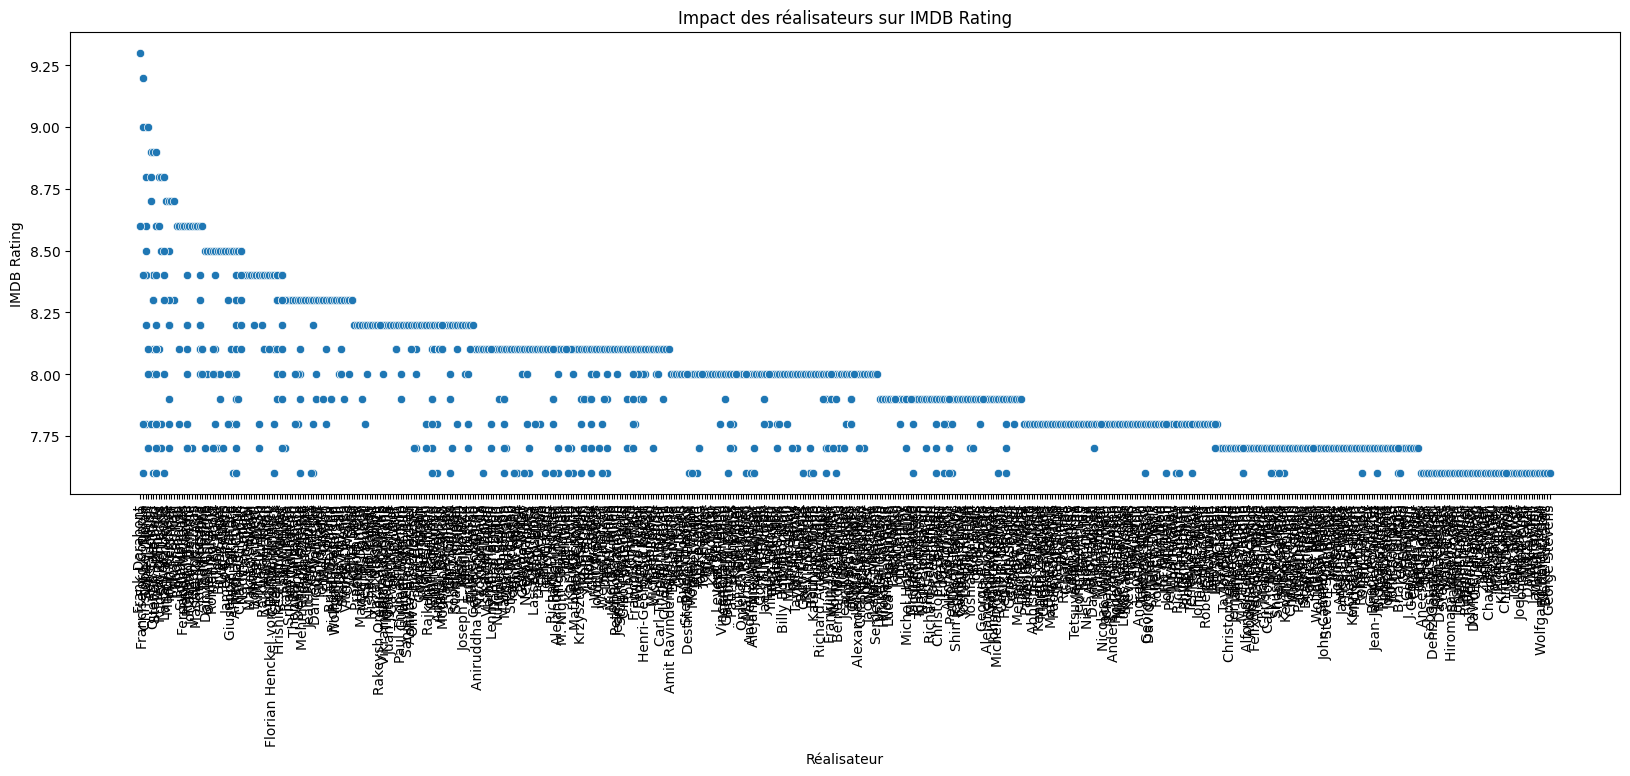

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(data=df, x='Director', y='IMDB_Rating')
plt.xticks(rotation=90)
plt.title("Impact des réalisateurs sur IMDB Rating")
plt.xlabel("Réalisateur")
plt.ylabel("IMDB Rating")
plt.show()


In [ ]:
unique_directors = len(set(df['Director']))
print(unique_directors)


548


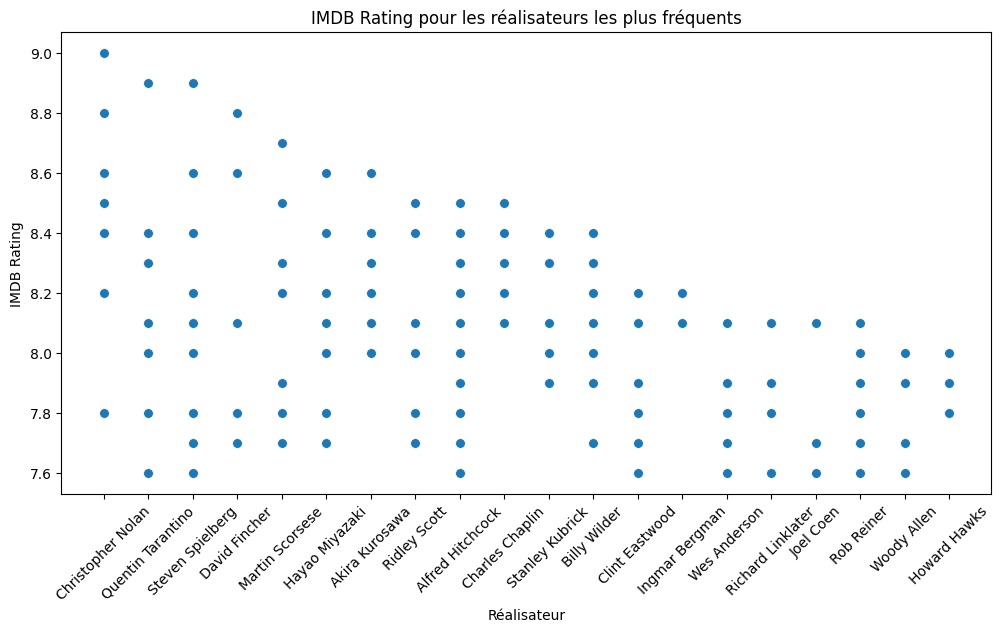

In [ ]:
# Top 20 réalisateurs les plus fréquents
top_directors = df['Director'].value_counts().nlargest(20).index
df_top = df[df['Director'].isin(top_directors)]

plt.figure(figsize=(12,6))
sns.scatterplot(data=df_top, x='Director', y='IMDB_Rating', s=50)
plt.xticks(rotation=45)
plt.title("IMDB Rating pour les réalisateurs les plus fréquents")
plt.xlabel("Réalisateur")
plt.ylabel("IMDB Rating")
plt.show()


**5️ Star Power Analysis (relation entre stars et ratings/gross)**

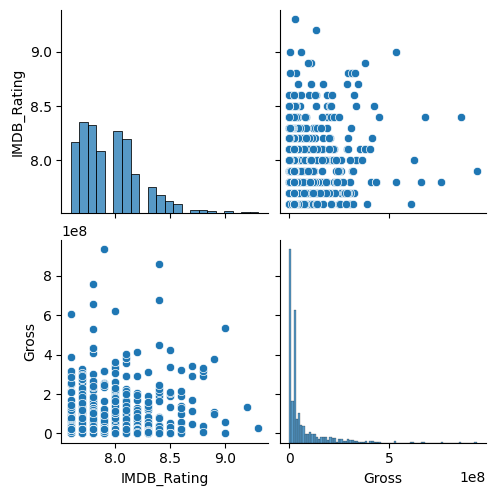

In [ ]:
# Sélection de colonnes Star et numériques
stars_cols = ['Star1', 'Star2', 'Star3', 'Star4']
numeric_cols = ['IMDB_Rating', 'Gross']

sns.pairplot(df[stars_cols + numeric_cols])
plt.show()


**6️ Box Plot of Genres vs. Ratings**

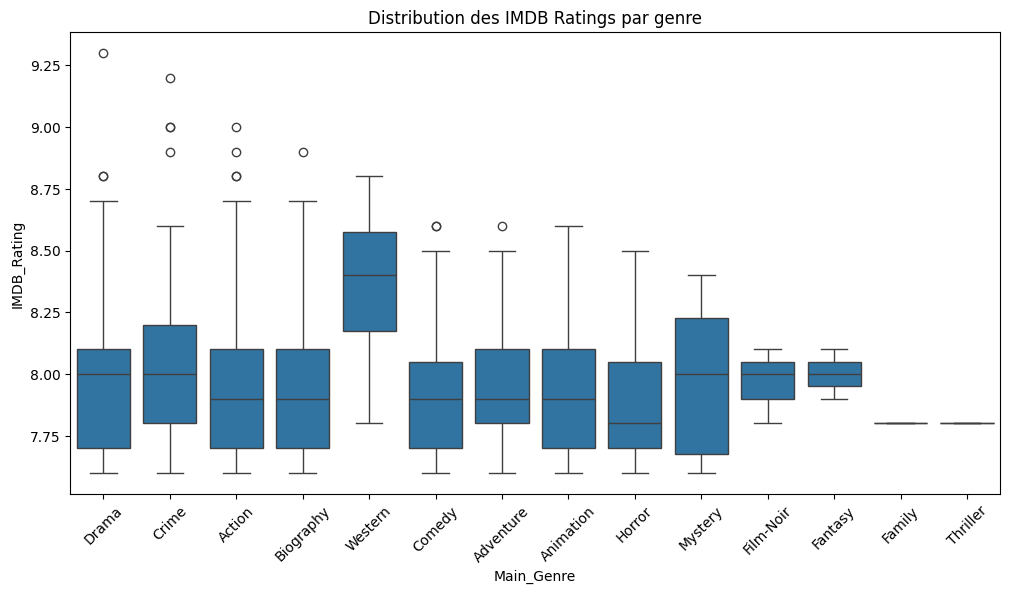

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Main_Genre', y='IMDB_Rating')
plt.xticks(rotation=45)
plt.title("Distribution des IMDB Ratings par genre")
plt.show()


**7️Correlation Heatmap**

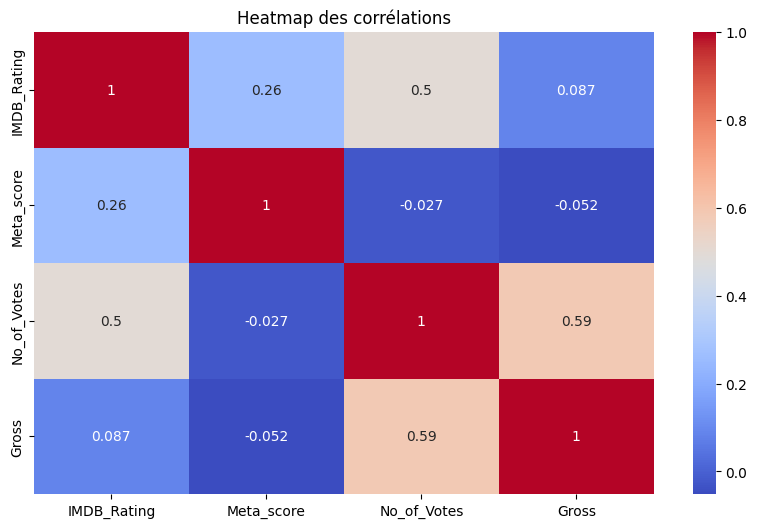

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap des corrélations")
plt.show()
